# 01 — Data Exploration & Labeling

This notebook explores the raw Reddit dataset:
- Size and shape of submissions, user_relations, users
- Subreddit activity distribution
- Political vs non-political split
- User ideology label distribution
- Time series of activity

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
DATA_RAW = Path("../data/raw")
DATA_PRO = Path("../data/processed")
OUT      = Path("../results/figures")
OUT.mkdir(parents=True, exist_ok=True)

## 1.1 Load processed data

In [2]:
submissions    = pd.read_parquet(DATA_PRO / "submissions.parquet")    if (DATA_PRO / "submissions.parquet").exists() \
                 else pd.read_csv(DATA_RAW / "submissions.csv", low_memory=False)
user_relations = pd.read_parquet(DATA_PRO / "user_relations.parquet") if (DATA_PRO / "user_relations.parquet").exists() \
                 else pd.read_csv(DATA_RAW / "user_relations.csv",     low_memory=False)
users          = pd.read_parquet(DATA_PRO / "users.parquet")          if (DATA_PRO / "users.parquet").exists() \
                 else pd.read_csv(DATA_RAW / "users.csv",              low_memory=False)

print(f"Submissions    : {len(submissions):>12,} rows | cols: {list(submissions.columns)}")
print(f"User relations : {len(user_relations):>12,} rows | cols: {list(user_relations.columns)}")
print(f"Users          : {len(users):>12,} rows | cols: {list(users.columns)}")

Submissions    :   12,670,489 rows | cols: ['post_id', 'author', 'subreddit', 'score']
User relations :   85,910,259 rows | cols: ['source_author', 'target_author', 'sentiment_sum', 'interaction_count']
Users          :    6,562,881 rows | cols: ['username']


## 1.2 Top subreddits by activity

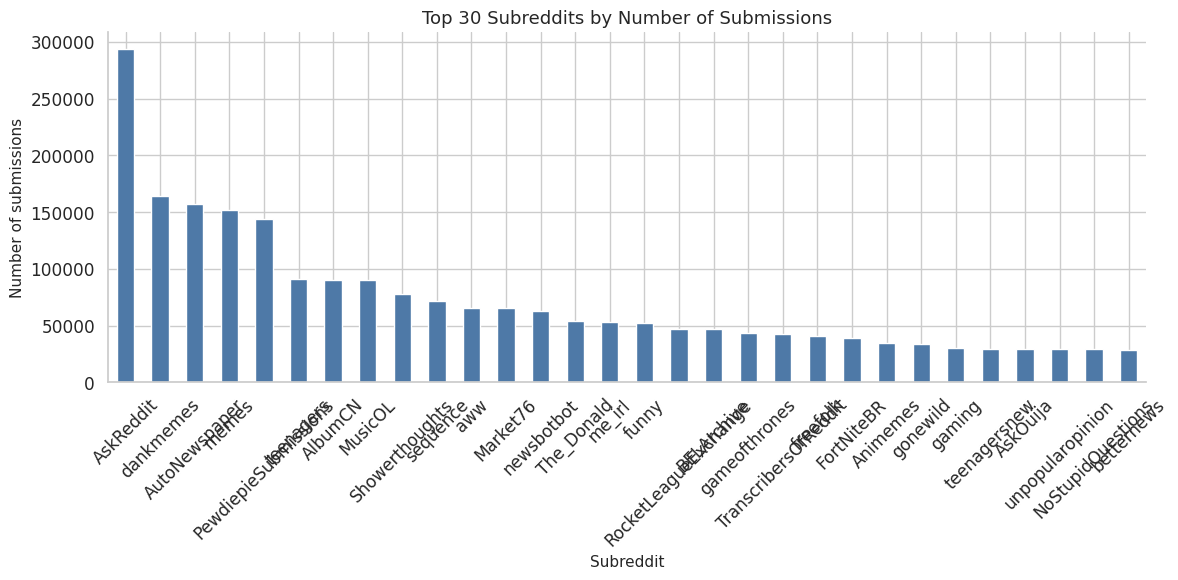

subreddit
AskReddit               293956
dankmemes               164468
AutoNewspaper           156843
memes                   151916
PewdiepieSubmissions    143737
teenagers                91499
AlbumCN                  90580
MusicOL                  90110
Showerthoughts           78129
sequence                 71800
aww                      65895
Market76                 65362
newsbotbot               62870
The_Donald               54388
me_irl                   53453
funny                    52631
RocketLeagueExchange     47490
BELArchive               47477
gameofthrones            43886
TranscribersOfReddit     43066
Name: count, dtype: int64


In [3]:
top_subs = submissions["subreddit"].value_counts().head(30)

fig, ax = plt.subplots(figsize=(12, 6))
top_subs.plot(kind="bar", ax=ax, color="#4e79a7", edgecolor="white")
ax.set_title("Top 30 Subreddits by Number of Submissions", fontsize=13)
ax.set_xlabel("Subreddit", fontsize=11)
ax.set_ylabel("Number of submissions", fontsize=11)
ax.tick_params(axis="x", rotation=45)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / "nb01_top_subs.png", dpi=130, bbox_inches="tight")
plt.show()
print(top_subs.head(20))

## 1.3 User activity distribution

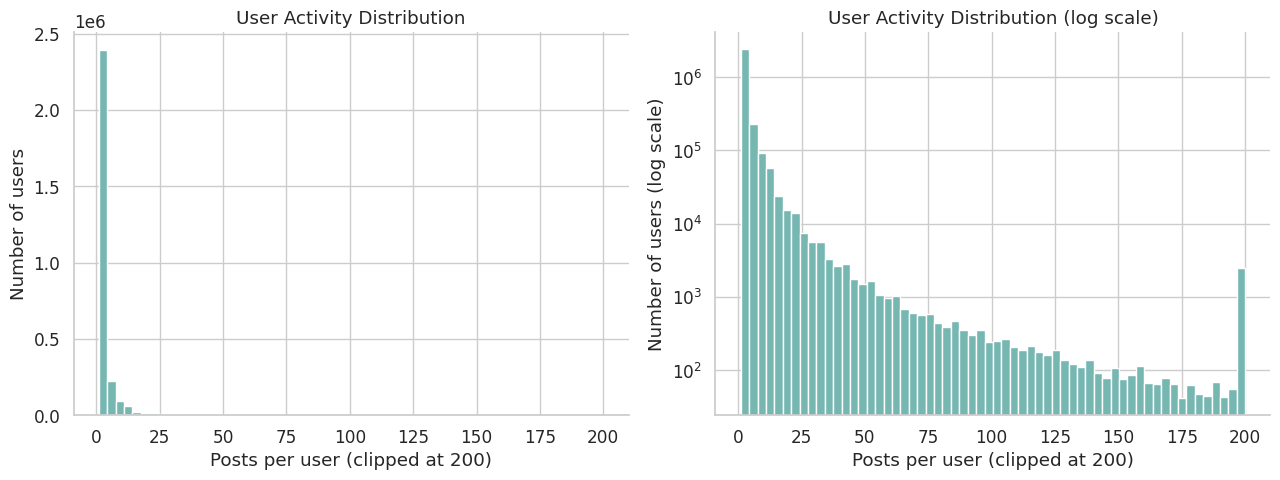

Unique authors       : 2,868,448
Median posts/user    : 2
Mean posts/user      : 4.4
Users with 1 post    : 1,395,486
Users with >100 posts: 5,850


In [4]:
user_activity = submissions.groupby("author").size().reset_index(name="n_posts")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(user_activity["n_posts"].clip(upper=200), bins=60,
             color="#76b7b2", edgecolor="white")
axes[0].set_xlabel("Posts per user (clipped at 200)")
axes[0].set_ylabel("Number of users")
axes[0].set_title("User Activity Distribution")
axes[0].spines[["top","right"]].set_visible(False)

axes[1].hist(user_activity["n_posts"].clip(upper=200), bins=60,
             color="#76b7b2", edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_xlabel("Posts per user (clipped at 200)")
axes[1].set_ylabel("Number of users (log scale)")
axes[1].set_title("User Activity Distribution (log scale)")
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT / "nb01_user_activity.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Unique authors       : {user_activity['author'].nunique():,}")
print(f"Median posts/user    : {user_activity['n_posts'].median():.0f}")
print(f"Mean posts/user      : {user_activity['n_posts'].mean():.1f}")
print(f"Users with 1 post    : {(user_activity['n_posts']==1).sum():,}")
print(f"Users with >100 posts: {(user_activity['n_posts']>100).sum():,}")

## 1.4 User ideology label distribution

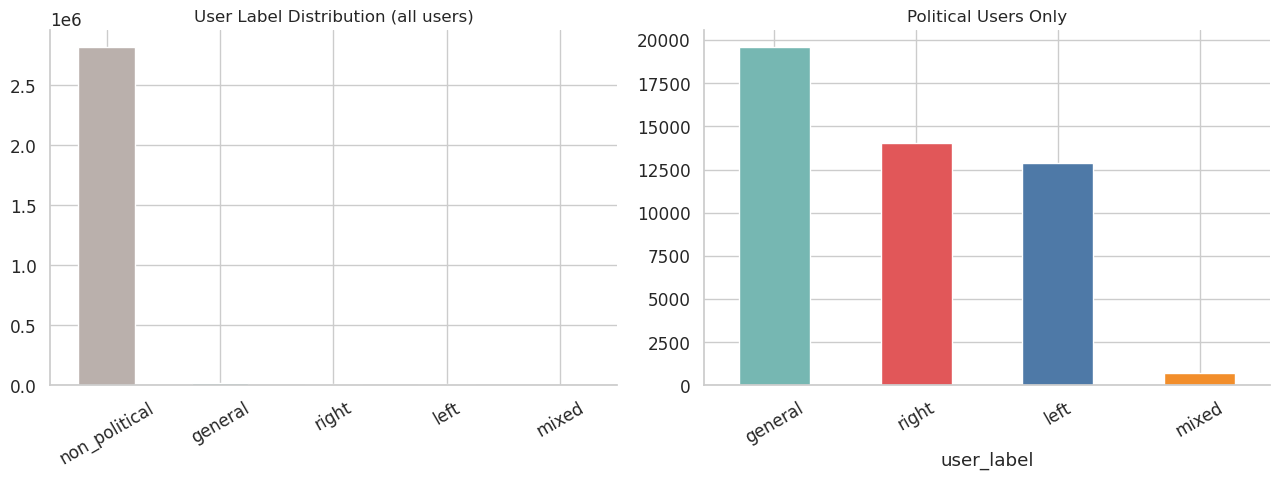

user_label
non_political    2818643
general            19606
right              14067
left               12899
mixed                741
Name: count, dtype: int64


In [5]:
user_labels = pd.read_parquet(DATA_PRO / "user_labels.parquet") if (DATA_PRO / "user_labels.parquet").exists() \
              else pd.read_csv(DATA_PRO / "user_labels.csv")

label_counts = user_labels["user_label"].value_counts()
COLORS = {"left":"#4e79a7","right":"#e15759","general":"#76b7b2",
          "non_political":"#bab0ac","mixed":"#f28e2b","unknown":"#d3d3d3"}
colors = [COLORS.get(l, "#aaa") for l in label_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

label_counts.plot(kind="bar", ax=axes[0], color=colors, edgecolor="white")
axes[0].set_title("User Label Distribution (all users)", fontsize=12)
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)
axes[0].spines[["top","right"]].set_visible(False)

pol = label_counts[label_counts.index.isin(["left","right","general","mixed"])]
pol_colors = [COLORS.get(l,"#aaa") for l in pol.index]
pol.plot(kind="bar", ax=axes[1], color=pol_colors, edgecolor="white")
axes[1].set_title("Political Users Only", fontsize=12)
axes[1].tick_params(axis="x", rotation=30)
axes[1].spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig(OUT / "nb01_user_labels.png", dpi=130, bbox_inches="tight")
plt.show()
print(label_counts)

## 1.5 Political vs non-political comment share

In [6]:
try:
    activity = pd.read_parquet(DATA_PRO / "activity.parquet")
except:
    activity = submissions.copy()

if "sub_ideology" in activity.columns:
    pol_counts = activity["sub_ideology"].value_counts()
    fig, ax = plt.subplots(figsize=(8, 5))
    pol_counts.plot(kind="bar", ax=ax,
                    color=["#d3d3d3","#bab0ac","#76b7b2","#e15759","#4e79a7"],
                    edgecolor="white")
    ax.set_title("Comment Distribution by Subreddit Ideology", fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(OUT / "nb01_ideology_split.png", dpi=130, bbox_inches="tight")
    plt.show()
    print(pol_counts)
else:
    print("sub_ideology column not found in activity table — check preprocessing output")

sub_ideology column not found in activity table — check preprocessing output


## 1.6 Summary statistics

In [7]:
print("=" * 50)
print("  DATASET SUMMARY")
print("=" * 50)
print(f"  Total submissions      : {len(submissions):>12,}")
print(f"  Total user_relations   : {len(user_relations):>12,}")
print(f"  Total users            : {len(users):>12,}")
print(f"  Unique subreddits      : {submissions['subreddit'].nunique():>12,}")
if 'user_label' in user_labels.columns:
    pol = user_labels[user_labels['user_label'].isin(['left','right'])]
    print(f"  Political users (L+R)  : {len(pol):>12,}")
    print(f"    Left                 : {(user_labels['user_label']=='left').sum():>12,}")
    print(f"    Right                : {(user_labels['user_label']=='right').sum():>12,}")
print("=" * 50)

  DATASET SUMMARY
  Total submissions      :   12,670,489
  Total user_relations   :   85,910,259
  Total users            :    6,562,881
  Unique subreddits      :      197,870
  Political users (L+R)  :       26,966
    Left                 :       12,899
    Right                :       14,067
